Chapter 02

# 一元高斯分布PDF
《概率统计》 | 鸢尾花书：数学不难

## 1. 定义连续随机变量的概率密度函数（PDF）

代码首先通过自定义函数计算高斯分布（或称正态分布）的概率密度函数，其数学对象是一个连续随机变量
$$X \sim \mathcal{N}(\mu,\sigma^2).$$

对任意实数 $x$，正态分布的 PDF 定义为：

$$
f_X(x)=\frac{1}{\sqrt{2\pi},\sigma}
\exp\left(
-\frac{1}{2}
\left(
\frac{x-\mu}{\sigma}
\right)^2
\right).
$$

函数 `gaussian_pdf` 内部所做的事情，就是完整计算上述公式中的两个关键部分：

* 常数系数部分
  $$\text{系数} = \frac{1}{\sqrt{2\pi},\sigma},$$
  这个系数保证整个 PDF 的积分为 1，也就是满足概率密度的归一化要求。

* 指数部分
  $$\text{指数} = -\frac12\left(\frac{x-\mu}{\sigma}\right)^2,$$
  控制曲线的形状：距离均值越远，密度越小。

最终得到的
$$\text{PDF} = \text{系数} \times e^{\text{指数}}$$
就是正态分布在每一个点 $x$ 的概率密度值。

---

## 2. 设置分布的基本参数

代码中选择
$$\mu = 0,\quad \sigma = 1,$$
即标准正态分布 $\mathcal{N}(0,1)$。
此时 PDF 变成：

$$
f_X(x)=\frac{1}{\sqrt{2\pi}}
\exp\left(
-\frac12 x^2
\right).
$$

这是最经典的钟形曲线，关于 $x=0$ 对称，在 $x=0$ 处达到最大值。

---

## 3. 构造连续自变量并计算 PDF 数值

为了从数学对象变成可视化图像，需要令 $x$ 在一个连续区间上取多个点。

代码中产生的区间是

$$x \in [-8,; 8],$$

并将这个区间分为 1000 个等距的点：

$$
x_1, x_2, \dots, x_{1000}.
$$

然后对每个点分别代入 PDF 函数，得到：

$$
f_X(x_i),\quad i=1,\dots,1000.
$$

这样便构成了真正可以绘图的数值向量。

---

## 4. 绘制概率密度函数曲线

在二维平面中，以横轴 $x$、纵轴 $f_X(x)$ 画出连续曲线。
这条曲线具有以下数学特征：

* 关于 $\mu$ 对称，即
  $$f_X(\mu + t) = f_X(\mu - t).$$
* 在 $x=\mu$ 处取得最大值
  $$f_X(\mu) = \frac{1}{\sqrt{2\pi}\sigma}.$$
* 当 $|x|$ 增大时，指数项
  $$\exp\left( -\frac12(\frac{x-\mu}{\sigma})^2 \right)$$
  快速衰减，使图像形成典型的“钟形”结构。

可视化的蓝色曲线正是这一数学函数的图形。

---

## 5. 绘制均值的垂直参考线

代码在 $x = \mu$ 的位置画一条红色虚线，即

$$x = 0.$$

这条线标示出“分布的中心”。数学上它具有重要意义，因为：

* 是分布的对称轴；
* 是随机变量期望值；
* 也是最大密度点。

图中这条竖线强化了正态分布围绕均值对称的概念。

---

## 6. 设置图像范围、刻度与网格

这些设置对应数学上的“观察窗口”：

* 横轴显示范围
  $$[-8, 8]$$
  远大于 $[-3\sigma, 3\sigma]$，确保尾部衰减行为完整展示。

* 纵轴范围
  $$[0, 0.5]$$
  足以容纳最高点 $1/\sqrt{2\pi}\approx0.398$。

* 网格线提供辅助视图，使密度的变化趋势更易读。

---

## 7. 整体数学意义总结

这段代码的数学目标是：

1. **定义一个高斯分布**
   $$X\sim\mathcal{N}(\mu,\sigma^2).$$

2. **计算其概率密度函数**
   $$f_X(x)=\frac{1}{\sqrt{2\pi}\sigma}e^{-(x-\mu)^2/(2\sigma^2)}.$$

3. **对连续区间的多个点进行数值评价**，得到密度值序列。

4. **将 PDF 曲线可视化**，并用垂直线明确分布中心位置。

最终的图像完整呈现出标准正态分布的对称性、峰值位置与尾部衰减结构。

## 可视化

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## 自定义函数，高斯分布PDF

In [6]:
def gaussian_pdf(x1, mu, sigma):
    coeff = 1.0 / (np.sqrt(2.0 * np.pi) * sigma)  
    # 计算归一化系数
    exponent = -0.5 * ((x1 - mu) / sigma) ** 2    
    # 计算指数部分
    pdf = coeff * np.exp(exponent)  
     # 返回概率密度值
    return pdf

## 设置参数

In [8]:
mu = 0
sigma = 1
# 定义 x 轴取值范围
x = np.linspace(-8, 8, 1000)

## 可视化

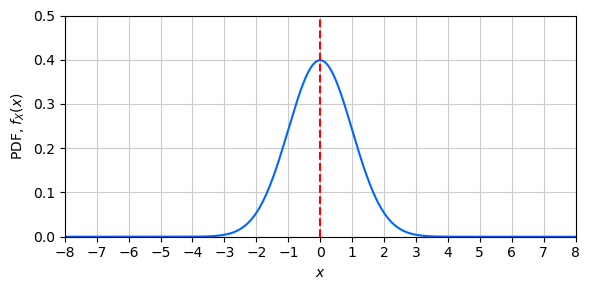

In [10]:
plt.figure(figsize=(6, 3))

pdf = gaussian_pdf(x, mu, sigma)  # 计算 PDF
plt.plot(x, pdf, color='#0066FF')  # 绘图
plt.axvline(x = mu, color = 'r', ls = '--')
plt.xlabel(r"$x$")
plt.ylabel(r"PDF, $f_{X}(x)$")
plt.grid(True, color = '0.8')
plt.xlim(-8, 8)
plt.xticks(np.arange(-8,9))
plt.ylim(0, 0.5)
plt.tight_layout()

作者	**生姜DrGinger**  
脚本	**生姜DrGinger**  
视频	**崔崔CuiCui**  
开源资源	[**GitHub**](https://github.com/Visualize-ML)  
平台	[**油管**](https://www.youtube.com/@DrGinger_Jiang)		
		[**iris小课堂**](https://space.bilibili.com/3546865719052873)		
		[**生姜DrGinger**](https://space.bilibili.com/513194466)  